<a href="https://colab.research.google.com/github/williamfaraday123/SC4001-Neural-Network/blob/main/Lim_Isaac_Part_B_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question B3 (10 marks)

Besides ensuring that your neural network performs well, it is important to be able to explain the model’s decision. **Captum** is a very handy library that helps you to do so for PyTorch models.

Many model explainability algorithms for deep learning models are available in Captum. These algorithms are often used to generate an attribution score for each feature. Features with larger scores are more ‘important’ and some algorithms also provide information about directionality (i.e. a feature with very negative attribution scores means the larger the value of that feature, the lower the value of the output).

In general, these algorithms can be grouped into two paradigms:
- **perturbation based approaches** (e.g. Feature Ablation)
- **gradient / backpropagation based approaches** (e.g. Saliency)

The former adopts a brute-force approach of removing / permuting features one by one and does not scale up well. The latter depends on gradients and they can be computed relatively quickly. But unlike how backpropagation computes gradients with respect to weights, gradients here are computed **with respect to the input**. This gives us a sense of how much a change in the input affects the model’s outputs.





---



---



In [1]:
!pip install captum

In [23]:
SEED = 42

import os

import random
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd

import torch
import torch.nn as nn
from torch import optim

from captum.attr import Saliency, DeepLift, IntegratedGradients, GradientShap, FeatureAblation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from captum.attr import Saliency, DeepLift, IntegratedGradients, GradientShap, FeatureAblation

import matplotlib.pyplot as plt
import seaborn as sns


1.First, load the dataset following the splits in Question B1. To keep things simple, we will **limit our analysis to numeric / continuous features only**. Drop all categorical features from the dataframes. Do not standardise the numerical features for now.



In [15]:
# YOUR CODE HERE
df = pd.read_csv('hdb_price_prediction.csv')

# Force 'year' to be numeric just in case it's stored as a string
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Check if the years actually exist in your data
print(f"Years found in dataset: {df['year'].unique()}")

# Splitting the data
train = df[df['year'] <= 2019].copy()
val = df[df['year'] == 2020].copy()
test = df[df['year'] == 2021].copy()


# Critical Check: Ensure these are NOT zero
print(f"Train size: {len(train)}")
print(f"Val size: {len(val)}")
print(f"Test size: {len(test)}")

if len(val) == 0:
    raise ValueError("Validation set is empty! Check if year 2020 exists in your CSV.")

# Define features
num_cols = [
    "dist_to_nearest_stn", "dist_to_dhoby", "degree_centrality",
    "eigenvector_centrality", "remaining_lease_years", "floor_area_sqm"
]
target_col = "resale_price"

# Drop the categorical columns for the model
X_train_raw = torch.tensor(train[num_cols].values, dtype=torch.float32)
X_test_raw = torch.tensor(test[num_cols].values, dtype=torch.float32)

y_train = torch.tensor(train[target_col].values, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(val[target_col].values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(test[target_col].values, dtype=torch.float32).view(-1, 1)

Years found in dataset: [2017 2018 2019 2020 2021 2022 2023]
Train size: 64057
Val size: 23313
Test size: 29057


2.Follow this tutorial to generate the plot from various model explainability algorithms (https://captum.ai/tutorials/House_Prices_Regression_Interpret).
Specifically, make the following changes:
- Use a feedforward neural network with 3 hidden layers, each having 5 neurons. Train using Adam optimiser with learning rate of 0.0005.
- Use Saliency, DeepLift, Integrated Gradients, GradientSHAP, Feature Ablation


In [16]:
# YOUR CODE HERE
class HDBModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_config_model(X, y):
    model = HDBModel(len(num_cols))
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.MSELoss()

    # Training loop
    model.train()
    for _ in range(100):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
    return model

model_raw = train_config_model(X_train_raw, y_train_t)

In [18]:
model_raw.eval()

# Initialize algorithms
sl = Saliency(model_raw)
dl = DeepLift(model_raw)
ig = IntegratedGradients(model_raw)
gs = GradientShap(model_raw)
fa = FeatureAblation(model_raw)

# Calculate attributions on test set
# For speed, you can use a subset: X_test_t[:100]
attr_sl = sl.attribute(X_test_raw)
attr_dl = dl.attribute(X_test_raw)
attr_ig = ig.attribute(X_test_raw)
attr_gs = gs.attribute(X_test_raw, baselines=X_train_raw) # Uses train distribution as baseline
attr_fa = fa.attribute(X_test_raw)

# Helper function to get mean absolute attribution
def get_avg_attr(attr):
    return np.abs(attr.detach().numpy()).mean(0)

# Collect data for plotting
importances = {
    'Saliency': get_avg_attr(attr_sl),
    'DeepLift': get_avg_attr(attr_dl),
    'Integrated Gradients': get_avg_attr(attr_ig),
    'GradientSHAP': get_avg_attr(attr_gs),
    'Feature Ablation': get_avg_attr(attr_fa)
}

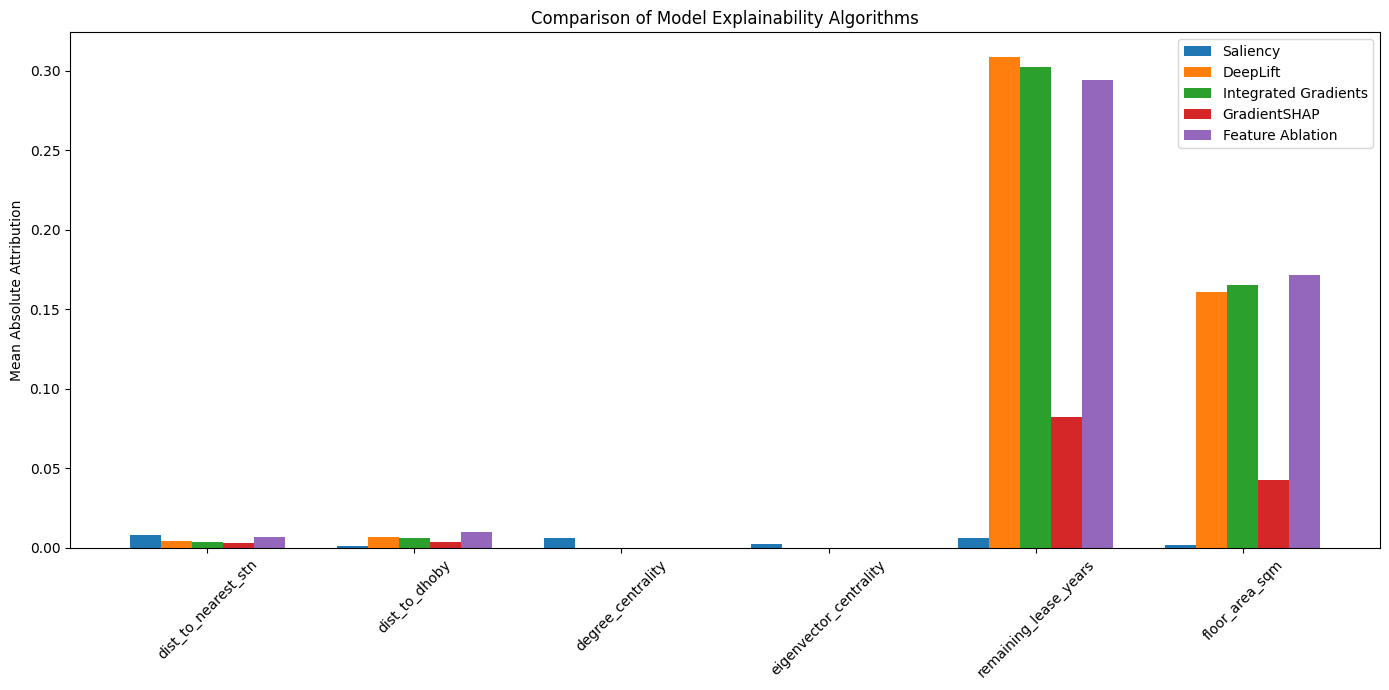

In [19]:
x_axis = np.arange(len(num_cols))
width = 0.15

plt.figure(figsize=(14, 7))

for i, (name, importances_val) in enumerate(importances.items()):
    plt.bar(x_axis + (i * width), importances_val, width, label=name)

plt.xticks(x_axis + width * 2, num_cols, rotation=45)
plt.ylabel('Mean Absolute Attribution')
plt.title('Comparison of Model Explainability Algorithms')
plt.legend()
plt.tight_layout()
plt.show()

3.Train a separate model with the same configuration but now standardise the features via **StandardScaler** (fit to training set, then transform all). State your observations with respect to GradientShap and explain why it has occurred.
(Hint: Many gradient-based approaches depend on a baseline, which is an important choice to be made. Check the default baseline settings carefully.)


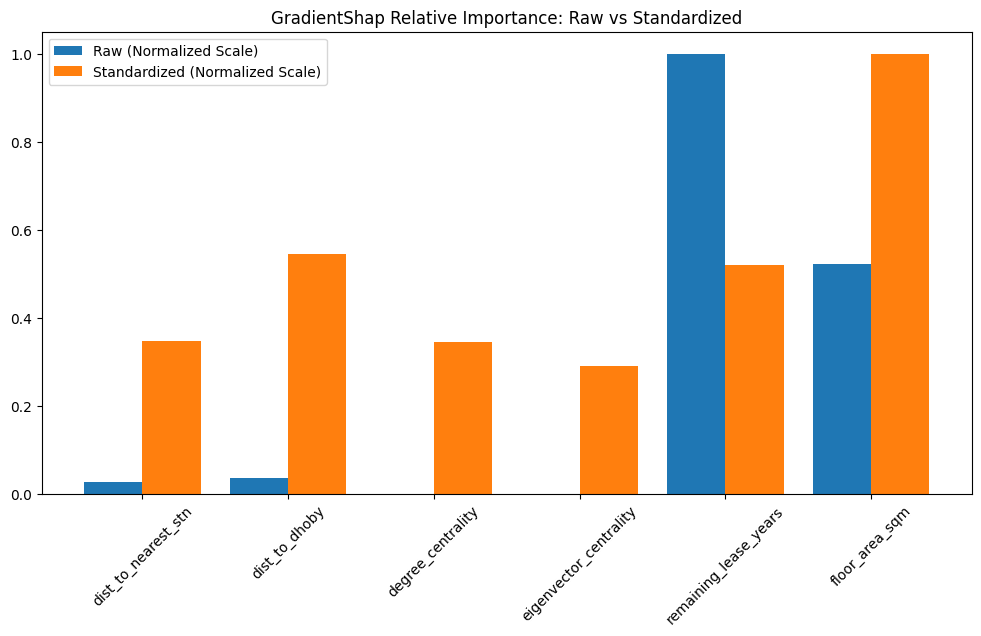

In [21]:
# YOUR CODE HERE
X_train_std = torch.tensor(scaler.fit_transform(train[num_cols]), dtype=torch.float32)
X_val_std = torch.tensor(scaler.fit_transform(val[num_cols]), dtype=torch.float32)
X_test_std = torch.tensor(scaler.transform(test[num_cols]), dtype=torch.float32)

model_std = train_config_model(X_train_std, y_train)

# --- 3. Attribution Logic ---
gs_raw = GradientShap(model_raw)
gs_std = GradientShap(model_std)

# Attribute (using training data as baselines)
attr_raw = gs_raw.attribute(X_test_raw[:200], baselines=X_train_raw).detach().numpy()
attr_std = gs_std.attribute(X_test_std[:200], baselines=X_train_std).detach().numpy()

# --- 4. Plotting ---
m_attr_raw = np.abs(attr_raw).mean(0)
m_attr_std = np.abs(attr_std).mean(0)

x = np.arange(len(num_cols))
plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, m_attr_raw / m_attr_raw.max(), 0.4, label='Raw (Normalized Scale)')
plt.bar(x + 0.2, m_attr_std / m_attr_std.max(), 0.4, label='Standardized (Normalized Scale)')
plt.xticks(x, num_cols, rotation=45)
plt.title("GradientShap Relative Importance: Raw vs Standardized")
plt.legend()
plt.show()

Read https://distill.pub/2020/attribution-baselines/ to build up your understanding of Integrated Gradients (IG). Reading the sections before the section on ‘Game Theory and Missingness’ will be sufficient. Keep in mind that this article mainly focuses on classification problems. You might find the following [descriptions](https://captum.ai/docs/attribution_algorithms) and [comparisons](https://captum.ai/docs/algorithms_comparison_matrix) in Captum useful as well.


Then, identify the algorithms that produced similar results, if any, and explain why in the context of our dataset. If no methods appear similar, discuss possible reasons for the differences


In [22]:
# YOUR ANSWER HERE

# to compute the mean absolute attribution for all five algorithms on standardized model
model_std.eval()

# Initialize all algorithms
algorithms = {
    "Saliency": Saliency(model_std),
    "DeepLift": DeepLift(model_std),
    "Integrated Gradients": IntegratedGradients(model_std),
    "GradientSHAP": GradientShap(model_std),
    "Feature Ablation": FeatureAblation(model_std)
}

# Dictionary to store mean attributions
attr_results = {}

for name, algo in algorithms.items():
    if name == "GradientSHAP":
        # GradientSHAP needs the training distribution as a baseline
        attr = algo.attribute(X_test_std, baselines=X_train_std, target=0)
    elif name in ["Integrated Gradients", "DeepLift"]:
        # These benefit from a zero baseline (the "average" flat in standardized data)
        attr = algo.attribute(X_test_std, target=0)
    else:
        attr = algo.attribute(X_test_std, target=0)

    # Store the mean absolute attribution per feature
    attr_results[name] = np.abs(attr.detach().numpy()).mean(0)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(attr_results, index=num_cols)
print(comparison_df)

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


                        Saliency  DeepLift  Integrated Gradients  \
dist_to_nearest_stn     0.012650  0.008325              0.008246   
dist_to_dhoby           0.015985  0.008631              0.008475   
degree_centrality       0.021578  0.007998              0.007995   
eigenvector_centrality  0.016095  0.004791              0.004945   
remaining_lease_years   0.015580  0.009967              0.009976   
floor_area_sqm          0.026302  0.011887              0.012178   

                        GradientSHAP  Feature Ablation  
dist_to_nearest_stn         0.011366          0.010752  
dist_to_dhoby               0.012010          0.013574  
degree_centrality           0.012326          0.009249  
eigenvector_centrality      0.007741          0.006312  
remaining_lease_years       0.010707          0.012695  
floor_area_sqm              0.021049          0.019525  


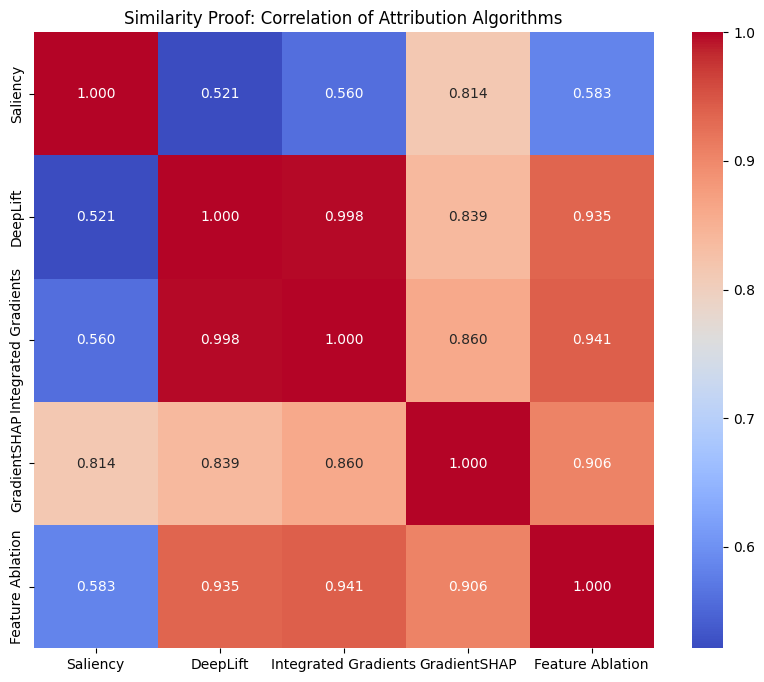

In [24]:
# Calculate the correlation matrix between algorithms
corr_matrix = comparison_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Similarity Proof: Correlation of Attribution Algorithms")
plt.show()

##Answer:

 Gradients (IG) and DeepLift are similar, as they have a high Pearson correlation of 0.998.
*   In smaller networks with ReLU activations, the model functions as a piecewise linear function. Both IG and DeepLift are designed to handle the "sum-to-diff" property, which ensures attributions sum up to the difference between the prediction and the baseline. Hence they converge to similar values when the underlying model transitions are not highly complex.
*   As discussed in the Distill paper, IG approximates the integral of gradients. DeepLift is a backpropagation-based approach that approximates the same "sum-to-diff" property. On a simple MLP with ReLU activations, these two mathematical paths converge to almost identical results.

